# 实验二
### 1.一幅图内同时绘制sin、cos、tan函数曲线图，区间长度为I，三条曲线线型、颜色各不相同。

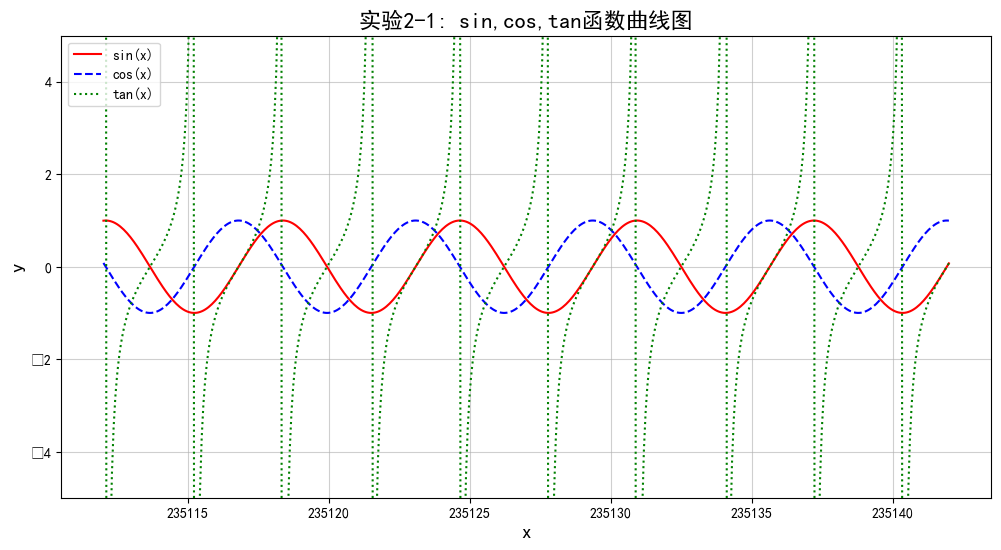

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
plt.rcParams['font.sans-serif'] = ['SimHei'] 

# 定义区间
x_start=235127-15
x_end=235127+15
# 生成x
x=np.linspace(x_start,x_end,500)
# 定义y
y_sin=np.sin(x)
y_cos=np.cos(x)
y_tan=np.tan(x)


plt.figure(figsize=(12, 6))
plt.plot(x,y_sin,label="sin(x)",color="red",linestyle="-")
plt.plot(x,y_cos,label="cos(x)",color="blue",linestyle="--")
plt.plot(x,y_tan,label="tan(x)",color="green",linestyle=":")

plt.title("实验2-1: sin,cos,tan函数曲线图",fontsize=16)
plt.xlabel("x",fontsize=14)
plt.ylabel("y",fontsize=14)

plt.legend()
plt.grid(True, alpha=0.6)# 网格线透明度

#这段为了避免科学计数法显示
ax = plt.gca() 
formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)

plt.ylim(-5, 5)
plt.show()


### 2. 绘制三维图形 x = sint-t*cost, y = cost-t*sint, z = t, t区间为I，图形x、y、z轴均加网格线，z轴取对数分布。

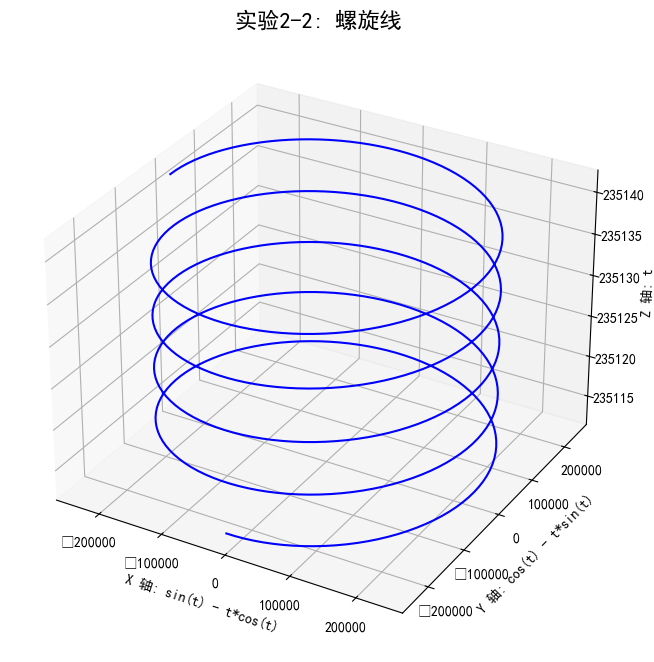

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import ScalarFormatter # 导入格式化工具,为了让z显示正确

t_start = 235112
t_end = 235142
t = np.linspace(t_start, t_end, 500)

x = np.sin(t) - t * np.cos(t)
y = np.cos(t) - t * np.sin(t)
z = t


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z, color='blue')

ax.set_xlabel('X 轴: sin(t) - t*cos(t)')
ax.set_ylabel('Y 轴: cos(t) - t*sin(t)')
ax.set_zlabel('Z 轴: t')
ax.set_title(f'实验2-2: 螺旋线', fontsize=16)

formatter = ScalarFormatter(useOffset=False)# 禁用偏移量
formatter.set_scientific(False)# 确保也不使用科学计数法

ax.zaxis.set_major_formatter(formatter) 
plt.show()

### 3、随机生成一组有效的50人班级的成绩，并绘制合理的统计直方图。提示：1、成绩为整数；2、直方图需选择合适区间。

生成的50个整数成绩: 
[ 71  60  76  85  67  74  76  72  82  78  91  79  90  81  69  65 100  61
  73  54  59  76  66  78  83  83  77  89  74  83  89  80  64  76  82  78
  66  75  76  74  78  73  57  51  93  95  69  84  81 100]


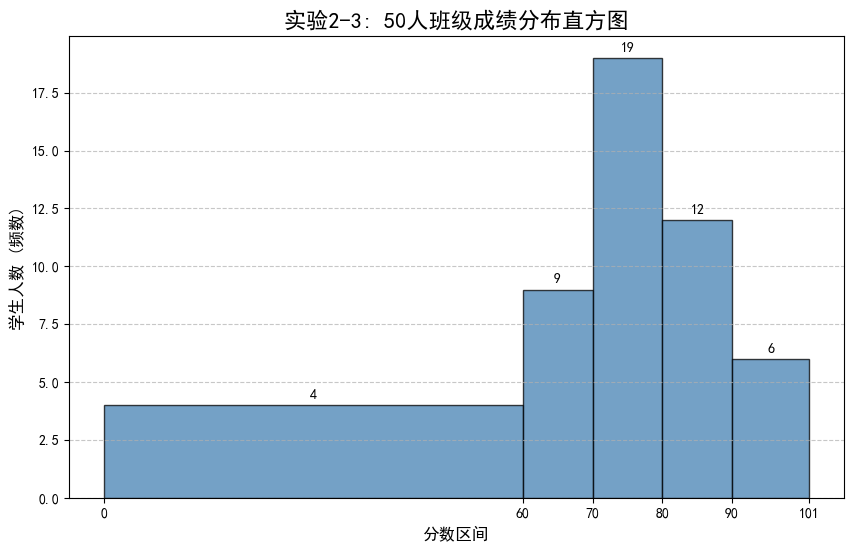

In [5]:
import numpy as np
import matplotlib.pyplot as plt

num_students = 50
mean_score = 75  # 目标平均分为 75
std_dev = 10     # 目标标准差为 10
# 生成 50 个标准正态分布 (均值为0, 标准差为1)
standard_normal_scores = np.random.randn(num_students)

# 将其平移和缩放, 得到分布 (均值为75, 标准差为10)
grades = standard_normal_scores * std_dev + mean_score

# 确保分数在 0 到 100 之间 (np.clip)
grades = np.clip(grades, 0, 100)
# 确保成绩为整数 (astype)
grades = grades.astype(int)

print(f"生成的50个整数成绩: \n{grades}")

plt.figure(figsize=(10, 6))

# 选择合适区间 (bins)
bins = [0, 60, 70, 80, 90, 101] # 0-59, 60-69, 70-79, 80-89, 90-100

# 绘制直方图 (并获取返回值以便后续添加标签)
counts, edges, _ = plt.hist(grades, 
                             bins=bins, 
                             color='steelblue', 
                             edgecolor='black', 
                             alpha=0.75)

plt.title('实验2-3: 50人班级成绩分布直方图', fontsize=16)
plt.xlabel('分数区间', fontsize=12)
plt.ylabel('学生人数 (频数)', fontsize=12)

# 设置 X 轴的刻度标签
plt.xticks(bins) 

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 在每个条形图上显示具体人数
bin_centers = 0.5 * (edges[:-1] + edges[1:]) # 计算每个区间的中心点
for count, x in zip(counts, bin_centers):
    if count > 0:
        plt.text(x, count + 0.2, str(int(count)), ha='center', va='bottom')

plt.show()

### 4. 统计自己十月份的各项支出，并利用软件绘制自己的支出饼状图，采用3种以上方式展示。

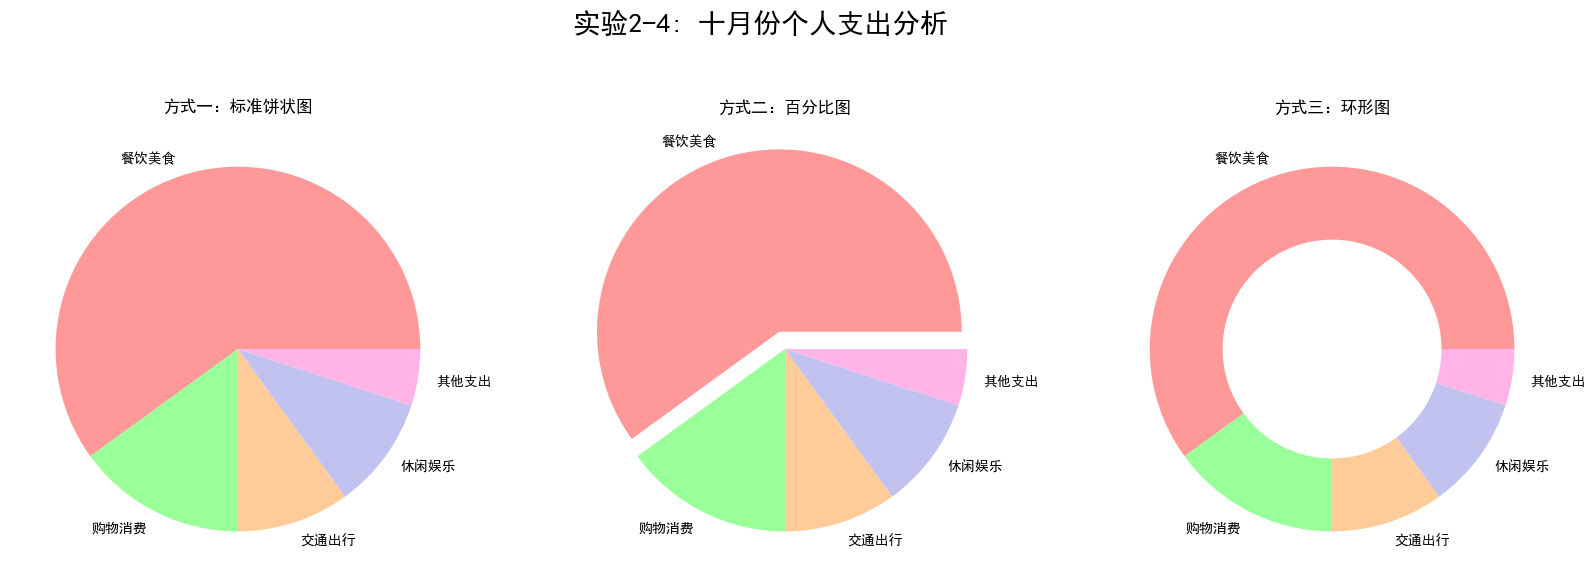

In [6]:
import matplotlib.pyplot as plt

labels = ['餐饮美食', '购物消费', '交通出行', '休闲娱乐', '其他支出']
sizes = [1200, 300, 200, 200, 100]
colors = ['#ff9999','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

# 函数式编程风格
plt.figure(figsize=(20, 7))

plt.subplot(1, 3, 1)
plt.pie(sizes, labels=labels, colors=colors)
plt.title('方式一：标准饼状图')

plt.subplot(1, 3, 2)
explode = (0.1, 0, 0, 0, 0) 
plt.pie(sizes, labels=labels, colors=colors, explode=explode)
plt.title('方式二：百分比图')

plt.subplot(1, 3, 3)
plt.pie(sizes, labels=labels, colors=colors, wedgeprops=dict(width=0.4))
plt.title('方式三：环形图')

plt.suptitle('实验2-4: 十月份个人支出分析', fontsize=20)
plt.show()

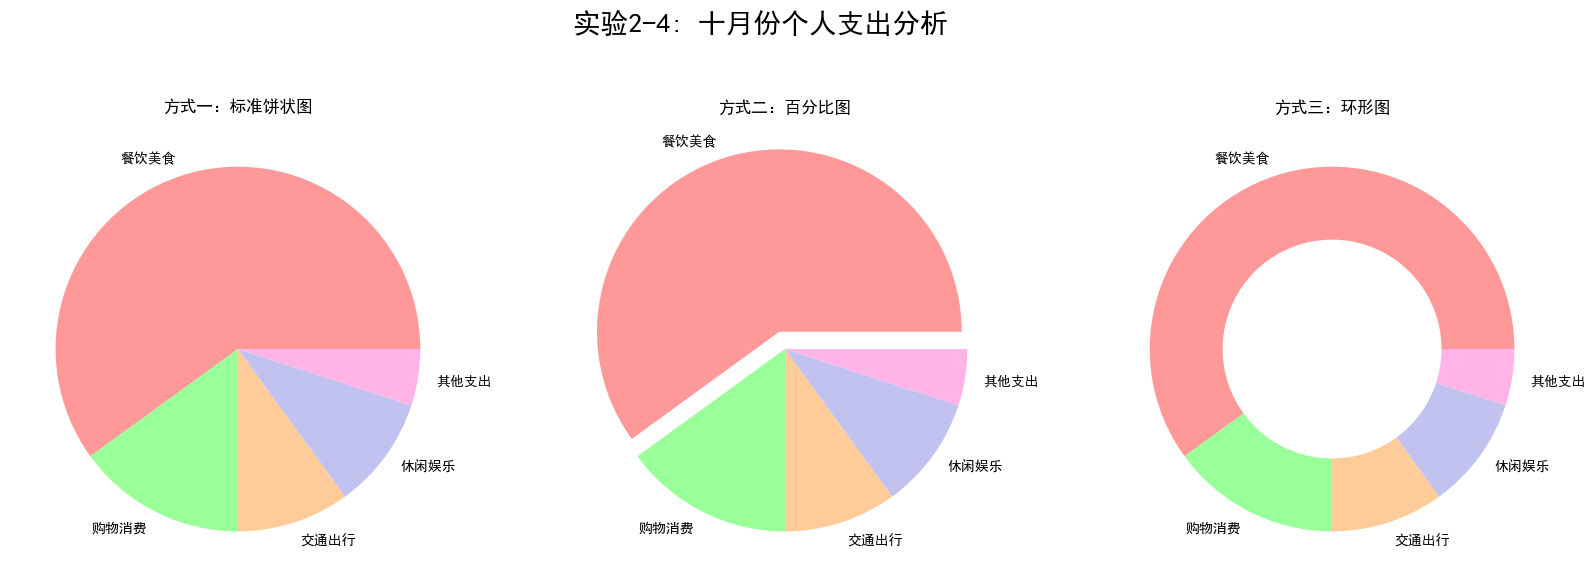

In [7]:
import matplotlib.pyplot as plt

labels = ['餐饮美食', '购物消费', '交通出行', '休闲娱乐', '其他支出']
sizes = [1200, 300, 200, 200, 100]
colors = ['#ff9999','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

# 面向对象风格
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7))

ax1.pie(sizes, labels=labels, colors=colors)
ax1.set_title('方式一：标准饼状图')

explode = (0.1, 0, 0, 0, 0) 
ax2.pie(sizes, labels=labels, colors=colors, explode=explode)
ax2.set_title('方式二：百分比图')

ax3.pie(sizes, labels=labels, colors=colors, wedgeprops=dict(width=0.4))
ax3.set_title('方式三：环形图')

fig.suptitle('实验2-4: 十月份个人支出分析', fontsize=20)
plt.show()

### 5. 绘制散点图x = sint-t*cost, y = cost-t*sint, t区间为I

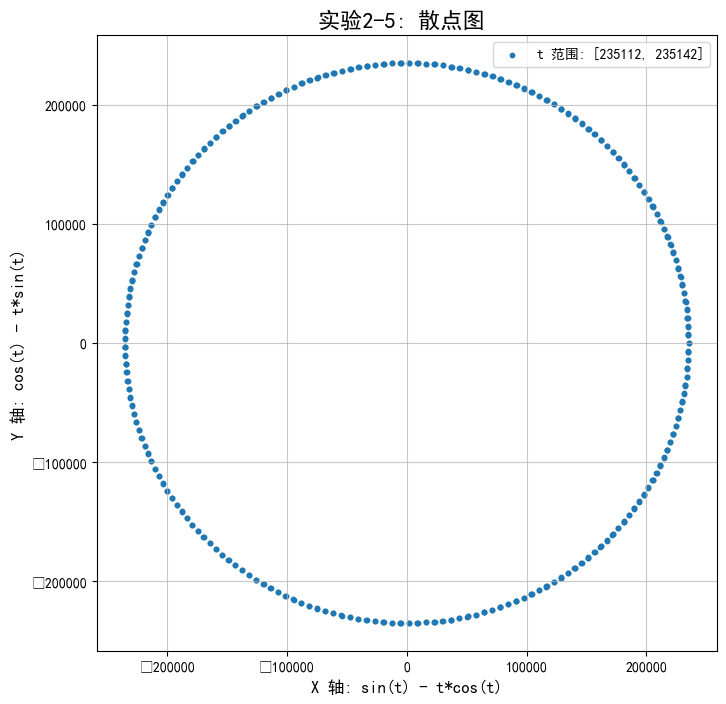

In [8]:
import matplotlib.pyplot as plt

t_start=235127-15
t_end=235127+15
t=np.linspace(t_start,t_end,500)

x = np.sin(t) - t * np.cos(t)
y = np.cos(t) - t * np.sin(t)

plt.figure(figsize=(8, 8)) 
plt.scatter(x, y, s=10, label=f't 范围: [{t_start}, {t_end}]')# 绘制散点图

plt.title('实验2-5: 散点图 ', fontsize=16)
plt.xlabel('X 轴: sin(t) - t*cos(t)', fontsize=12)
plt.ylabel('Y 轴: cos(t) - t*sin(t)', fontsize=12)

plt.grid(True, linestyle='-', alpha=0.7)

plt.legend() 
plt.show()

### 6.绘制曲线图、阶梯图x = sint-t*cost, y = cost-t*sint, t区间为I

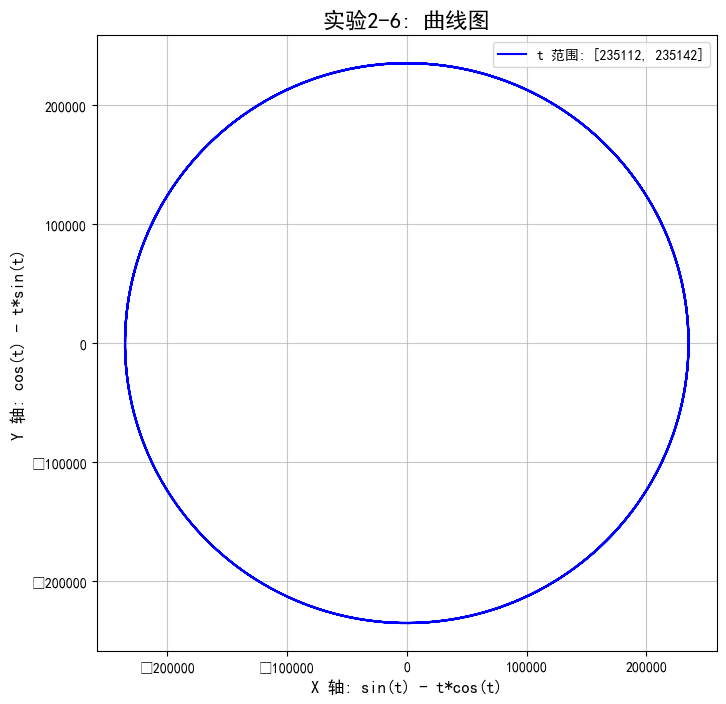

In [9]:
import numpy as np
import matplotlib.pyplot as plt

t_start=235127-15
t_end=235127+15
t=np.linspace(t_start,t_end,500)

x = np.sin(t) - t * np.cos(t)
y = np.cos(t) - t * np.sin(t)

plt.figure(figsize=(8, 8)) 
plt.plot(x, y, label=f't 范围: [{t_start}, {t_end}]', color='blue')# 绘制曲线图

plt.title('实验2-6: 曲线图', fontsize=16)
plt.xlabel('X 轴: sin(t) - t*cos(t)', fontsize=12)
plt.ylabel('Y 轴: cos(t) - t*sin(t)', fontsize=12)

plt.grid(True, linestyle='-', alpha=0.7) 

plt.legend() 
plt.show()

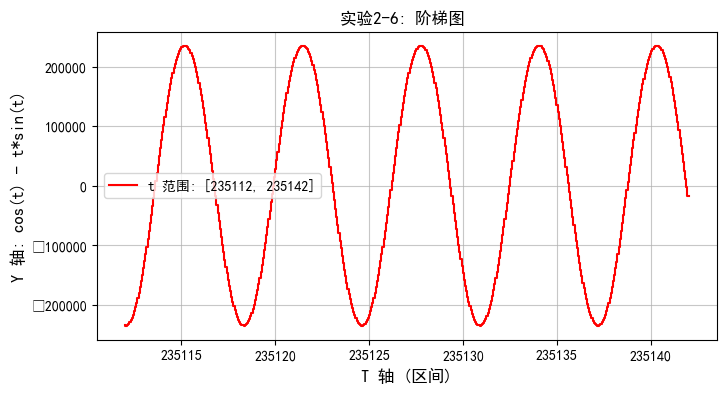

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

t_start=235127-15
t_end=235127+15
t=np.linspace(t_start,t_end,500)

x = np.sin(t) - t * np.cos(t)
y = np.cos(t) - t * np.sin(t)

plt.figure(figsize=(8, 4)) 
plt.step(t, y, label=f't 范围: [{t_start}, {t_end}]', color='red')# 绘制阶梯图

plt.title('实验2-6: 阶梯图 ', fontsize=12)
plt.xlabel('T 轴 (区间)', fontsize=12)
plt.ylabel('Y 轴: cos(t) - t*sin(t)', fontsize=12)
    
plt.grid(True, linestyle='-', alpha=0.7) 

#这段为了避免科学计数法显示
ax = plt.gca() 
formatter = ScalarFormatter(useOffset=False)
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)

plt.legend() 
plt.show()